In [ ]:
%pip install torch gensim pandas scikit-learn matplotlib seaborn nltk

In [2]:
import copy
import re
import time
from collections import Counter

import gensim.downloader as api
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

nltk.download("punkt_tab")
nltk.download("wordnet")

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

Using device: mps


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/imakarov/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/imakarov/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
DATA_DIR = "./data"
TRAIN_PATH = f"{DATA_DIR}/balanced_train.csv"
TEST_PATH = f"{DATA_DIR}/balanced_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Training set: {len(df_train)} records, {df_train['condition'].nunique()} conditions")
print(f"Test set:     {len(df_test)} records, {df_test['condition'].nunique()} conditions")
print(f"\nTrain class distribution:\n{df_train['condition'].value_counts()}")
df_train[["drugName", "condition", "review"]].head()

Training set: 29489 records, 10 conditions
Test set:     22070 records, 10 conditions

Train class distribution:
condition
Anxiety            3522
Birth Control      3522
Pain               3522
Depression         3522
Acne               3198
Bipolar Disorde    2693
Insomnia           2639
Weight Loss        2474
Obesity            2325
ADHD               2072
Name: count, dtype: int64


,drugName,condition,review
0,Hydroxyzine,Anxiety,"""This drug does well for the purpose it was pr..."
1,Olanzapine,Bipolar Disorde,"""Zyprexa has given me my life back in 4 weeks!..."
2,NuvaRing,Birth Control,"""Went on the ring two years ago. Was ok with i..."
3,Etonogestrel,Birth Control,"""I got Nexplanon 10/25/12 2 weeks after the bi..."
4,Tramadol,Pain,"""Tramadol made me so queasy that I couldn't si..."


In [4]:
DRUG_PLACEHOLDER = "drugname"
LEMMATIZER = WordNetLemmatizer()


def preprocess_review(text: str, drug_name: str) -> list[str]:
    """LSTM preprocessing: mask drug name, lowercase, tokenize, lemmatize."""
    if pd.isna(text) or not str(text).strip():
        return []

    text = str(text)

    if pd.notna(drug_name) and str(drug_name).strip():
        pattern = r"\b" + re.escape(str(drug_name)) + r"\b"
        text = re.sub(pattern, DRUG_PLACEHOLDER, text, flags=re.IGNORECASE)

    text = text.lower()
    tokens = word_tokenize(text)
    return [LEMMATIZER.lemmatize(tok) for tok in tokens]


sample = df_train.iloc[0]
print(f"Original:  {sample['review'][:200]}...")
print(f"Drug name: {sample['drugName']}")
tokens = preprocess_review(sample["review"], sample["drugName"])
print(f"Tokens ({len(tokens)}): {tokens[:25]}...")

Original:  "This drug does well for the purpose it was prescribed for: reduction of anxiety. However I commonly suffer from sleep walking, sleep motions and even talking. This drug really kicked all of that into...
Drug name: Hydroxyzine
Tokens (98): ['``', 'this', 'drug', 'doe', 'well', 'for', 'the', 'purpose', 'it', 'wa', 'prescribed', 'for', ':', 'reduction', 'of', 'anxiety', '.', 'however', 'i', 'commonly', 'suffer', 'from', 'sleep', 'walking', ',']...


In [5]:
start = time.time()
df_train["tokens"] = df_train.apply(
    lambda row: preprocess_review(row["review"], row["drugName"]),
    axis=1,
)
print(f"Train preprocessing: {time.time() - start:.1f}s")

start = time.time()
df_test["tokens"] = df_test.apply(
    lambda row: preprocess_review(row["review"], row["drugName"]),
    axis=1,
)
print(f"Test preprocessing:  {time.time() - start:.1f}s")

lengths = df_train["tokens"].str.len()
print(f"\nToken-length stats (train):\n{lengths.describe().astype(int)}")
print(f"\n95th percentile: {int(lengths.quantile(0.95))}")
print(f"99th percentile: {int(lengths.quantile(0.99))}")

Train preprocessing: 13.0s
Test preprocessing:  9.9s

Token-length stats (train):
count    29489
mean       101
std         50
min          5
25%         61
50%        103
75%        148
max       1196
Name: tokens, dtype: int64

95th percentile: 168
99th percentile: 178


In [6]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1
MIN_FREQ = 2

all_tokens = [tok for tokens in df_train["tokens"] for tok in tokens]
token_counts = Counter(all_tokens)

vocab = [PAD_TOKEN, UNK_TOKEN] + [
    word
    for word, count in token_counts.most_common()
    if count >= MIN_FREQ
]
word2idx: dict[str, int] = {word: idx for idx, word in enumerate(vocab)}

labels = sorted(df_train["condition"].unique())
label2idx: dict[str, int] = {label: idx for idx, label in enumerate(labels)}
idx2label: dict[int, str] = {idx: label for label, idx in label2idx.items()}

print(f"Vocabulary size: {len(vocab)} (min_freq={MIN_FREQ})")
print(f"Number of classes: {len(labels)}")
print(f"Classes: {labels}")

Vocabulary size: 14870 (min_freq=2)
Number of classes: 10
Classes: ['ADHD', 'Acne', 'Anxiety', 'Bipolar Disorde', 'Birth Control', 'Depression', 'Insomnia', 'Obesity', 'Pain', 'Weight Loss']


In [7]:
print("Loading pre-trained FastText vectors (~958 MB, cached after first download)...")
start = time.time()
fasttext_vectors = api.load("fasttext-wiki-news-subwords-300")
elapsed = time.time() - start
print(f"Loaded in {elapsed:.1f}s  |  {len(fasttext_vectors)} words, {fasttext_vectors.vector_size}d")

EMBEDDING_DIM = fasttext_vectors.vector_size

embedding_matrix = np.zeros((len(vocab), EMBEDDING_DIM), dtype=np.float32)
found = 0

for word, idx in word2idx.items():
    if word in (PAD_TOKEN, UNK_TOKEN):
        continue

    if word in fasttext_vectors:
        embedding_matrix[idx] = fasttext_vectors[word]
        found += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=EMBEDDING_DIM).astype(np.float32)

total = len(vocab) - 2
print(f"Embedding coverage: {found}/{total} ({found / total * 100:.1f}%)")

del fasttext_vectors

Loading pre-trained FastText vectors (~958 MB, cached after first download)...
Loaded in 167.5s  |  999999 words, 300d
Embedding coverage: 12436/14868 (83.6%)


In [8]:
# ── Architecture (tweak to experiment) ──────────────────────────────
HIDDEN_SIZE = 128          # LSTM hidden dim  (try 128 / 256)
NUM_LAYERS = 2            # Stacked LSTM layers (try 1 / 2)
DROPOUT = 0.3
FREEZE_EMBEDDINGS = True

# ── Sequence handling ──────────────────────────────────────────────
MAX_SEQ_LEN = 200          # Truncate / pad reviews to this length

# ── Training ───────────────────────────────────────────────────────
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
VAL_RATIO = 0.15           # Fraction of training data held out for validation

# ── Early stopping & LR scheduler ─────────────────────────────────
ES_PATIENCE = 5            # Stop after N epochs without val-loss improvement
LR_PATIENCE = 2            # Reduce LR after N stagnant epochs
LR_FACTOR = 0.5            # Multiply LR by this on plateau

In [9]:
class ReviewDataset(Dataset):
    def __init__(
        self,
        tokens_list: list[list[str]],
        labels: list[str],
        word2idx: dict[str, int],
        label2idx: dict[str, int],
        max_len: int,
    ) -> None:
        self.tokens_list = tokens_list
        self.labels = labels
        self.word2idx = word2idx
        self.label2idx = label2idx
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.tokens_list)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        tokens = self.tokens_list[idx][: self.max_len]
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        indices += [PAD_IDX] * (self.max_len - len(indices))

        return (
            torch.tensor(indices, dtype=torch.long),
            torch.tensor(self.label2idx[self.labels[idx]], dtype=torch.long),
        )


train_tokens, val_tokens, train_labels, val_labels = train_test_split(
    df_train["tokens"].tolist(),
    df_train["condition"].tolist(),
    test_size=VAL_RATIO,
    random_state=42,
    stratify=df_train["condition"],
)

train_ds = ReviewDataset(train_tokens, train_labels, word2idx, label2idx, MAX_SEQ_LEN)
val_ds = ReviewDataset(val_tokens, val_labels, word2idx, label2idx, MAX_SEQ_LEN)
test_ds = ReviewDataset(
    df_test["tokens"].tolist(),
    df_test["condition"].tolist(),
    word2idx,
    label2idx,
    MAX_SEQ_LEN,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Train: 25065  |  Val: 4424  |  Test: 22070


In [10]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix: np.ndarray,
        hidden_size: int,
        num_layers: int,
        num_classes: int,
        dropout: float,
        freeze_embeddings: bool = False,
    ) -> None:
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            padding_idx=PAD_IDX,
            freeze=freeze_embeddings,
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        # hidden shape: (num_layers * 2, batch, hidden_size)
        # last layer forward = hidden[-2], last layer backward = hidden[-1]
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))


model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=len(labels),
    dropout=DROPOUT,
    freeze_embeddings=FREEZE_EMBEDDINGS,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\n{model}")

Total parameters:     5,299,154
Trainable parameters: 838,154

BiLSTMClassifier(
  (embedding): Embedding(14870, 300, padding_idx=0)
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=10, bias=True)
)


In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
)

history: dict[str, list[float]] = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}
best_val_loss = float("inf")
best_model_state: dict | None = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(dim=1) == targets).sum().item()
        train_total += inputs.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(dim=1) == targets).sum().item()
            val_total += inputs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"train loss {train_loss:.4f}  acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}  acc {val_acc:.4f} | "
        f"lr {lr:.2e}"
    )

    # ── Early stopping ─────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= ES_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val_loss={best_val_loss:.4f})")

Epoch  1/20 | train loss 1.8821  acc 0.2762 | val loss 1.5759  acc 0.4123 | lr 1.00e-03
Epoch  2/20 | train loss 1.2747  acc 0.5169 | val loss 1.1337  acc 0.5769 | lr 1.00e-03
Epoch  3/20 | train loss 1.0297  acc 0.6315 | val loss 0.9670  acc 0.6519 | lr 1.00e-03
Epoch  4/20 | train loss 0.8620  acc 0.6975 | val loss 0.8824  acc 0.6930 | lr 1.00e-03
Epoch  5/20 | train loss 0.7710  acc 0.7256 | val loss 0.7624  acc 0.7224 | lr 1.00e-03
Epoch  6/20 | train loss 0.6850  acc 0.7547 | val loss 0.7383  acc 0.7432 | lr 1.00e-03
Epoch  7/20 | train loss 0.6319  acc 0.7684 | val loss 0.6854  acc 0.7439 | lr 1.00e-03
Epoch  8/20 | train loss 0.5994  acc 0.7802 | val loss 0.6335  acc 0.7611 | lr 1.00e-03
Epoch  9/20 | train loss 0.5642  acc 0.7905 | val loss 0.6392  acc 0.7701 | lr 1.00e-03
Epoch 10/20 | train loss 0.5306  acc 0.8011 | val loss 0.6352  acc 0.7665 | lr 1.00e-03
Epoch 11/20 | train loss 0.5070  acc 0.8103 | val loss 0.6511  acc 0.7663 | lr 5.00e-04
Epoch 12/20 | train loss 0.4555 

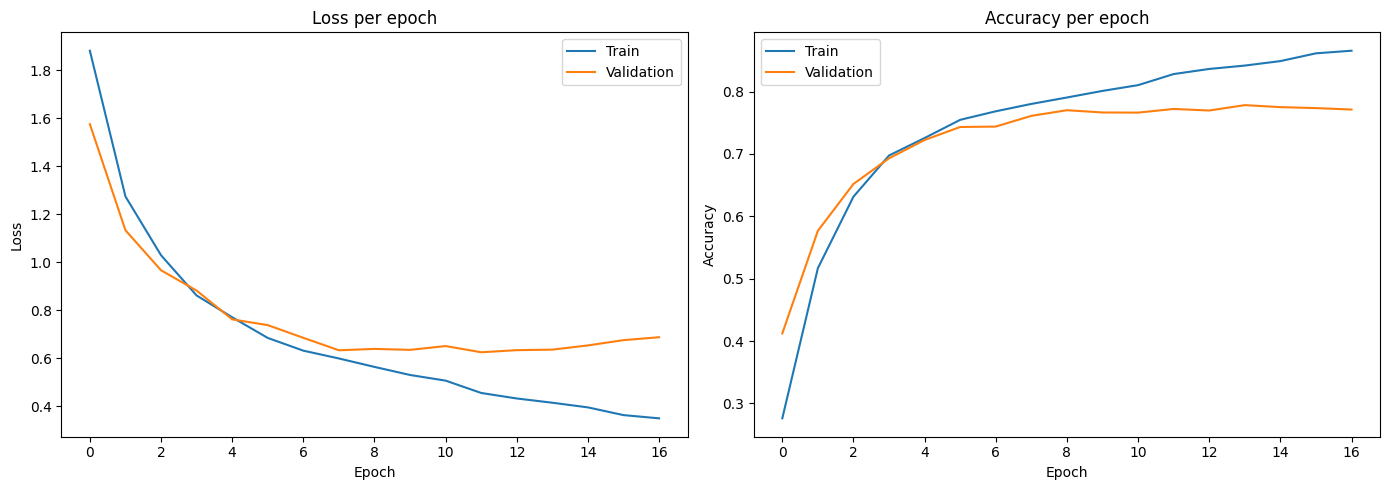

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
model.eval()
all_preds: list[int] = []
all_targets: list[int] = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
        all_targets.extend(targets.tolist())

y_pred = [idx2label[p] for p in all_preds]
y_true = [idx2label[t] for t in all_targets]

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")

Test accuracy: 0.8359

Classification Report:
                 precision    recall  f1-score   support

           ADHD       0.82      0.84      0.83       980
           Acne       0.86      0.92      0.89      1693
        Anxiety       0.75      0.71      0.73      1747
Bipolar Disorde       0.68      0.74      0.71      1236
  Birth Control       0.97      0.95      0.96      8402
     Depression       0.77      0.70      0.73      2798
       Insomnia       0.79      0.87      0.83      1127
        Obesity       0.58      0.35      0.43      1054
           Pain       0.87      0.92      0.89      1896
    Weight Loss       0.54      0.78      0.64      1137

       accuracy                           0.84     22070
      macro avg       0.76      0.78      0.77     22070
   weighted avg       0.84      0.84      0.83     22070



Withuot Lemmatization 1 layer: 81%  
With Lemmatization 1 layer: 84%  
With Lemmatization 2 layer: 84%

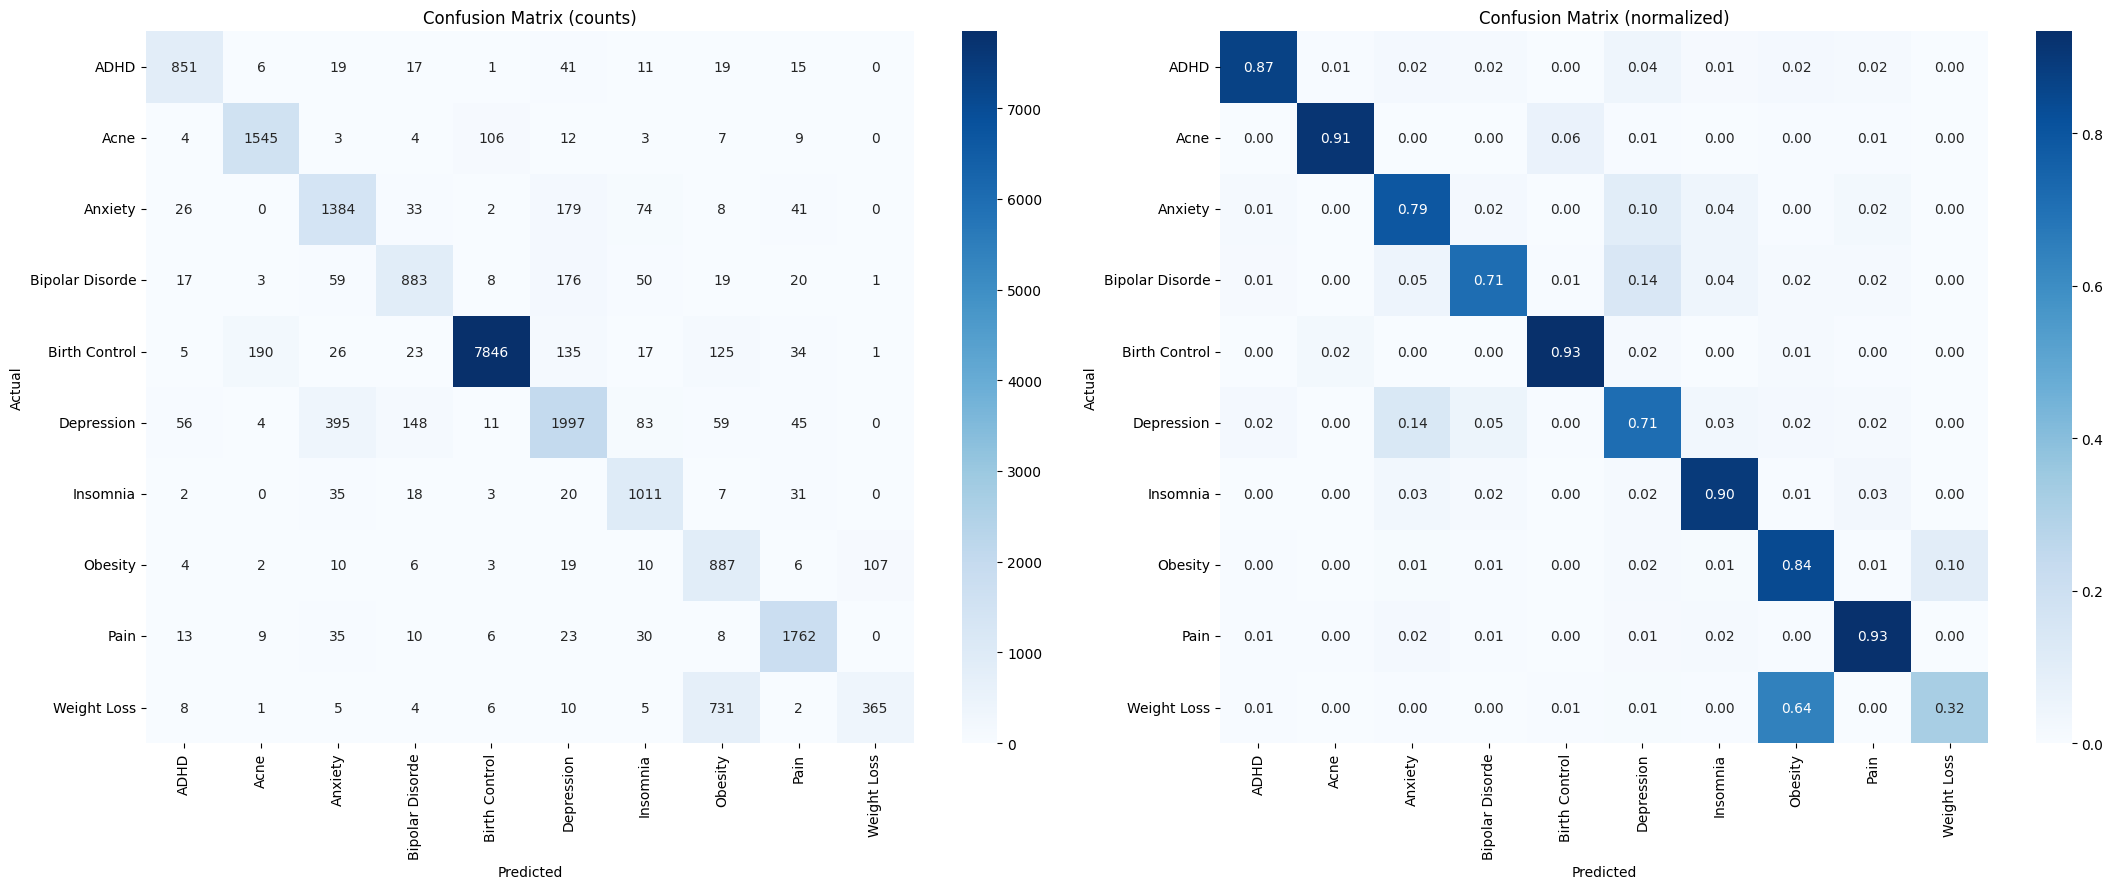

In [13]:
sorted_labels = sorted(set(y_true))
cm = confusion_matrix(y_true, y_pred, labels=sorted_labels)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted_labels,
    yticklabels=sorted_labels,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=sorted_labels,
    yticklabels=sorted_labels,
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()